<a href="https://colab.research.google.com/github/adi23042008-byte/aiml-bootcamp-2026/blob/main/aiml_bootcamp_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Calculate the avg marks and prin t class fialed or passed is the avg is 50 or above

In [ ]:

marks = [45, 60, 72, 38, 90]

total = 0

for i in range(len(marks) - 1):
    total += marks[i]

average = total / len(marks)

if average > 50:
    print("Class passed")
else:
    print("Class failed")
print("Average:",average)

Class failed
Average: 43.0


In [ ]:
import pandas as pd

In [ ]:
data = {
    "student_id": [101, 102, 103, 104, 105, 106],
    "attendance_percent": [92, 67, 81, 45, 74, 88],
    "assignment_score": [18, 12, 15, 8, 14, 19],
    "quiz_score": [72, 48, 65, 30, 55, 80],
    "lab_completed": [True, False, True, False, True, True]
}

df = pd.DataFrame(data)

df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True
5,106,88,19,80,True


In [ ]:
df.shape

(6, 5)

In [ ]:
df.head()

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   student_id          6 non-null      int64
 1   attendance_percent  6 non-null      int64
 2   assignment_score    6 non-null      int64
 3   quiz_score          6 non-null      int64
 4   lab_completed       6 non-null      bool 
dtypes: bool(1), int64(4)
memory usage: 330.0 bytes


In [ ]:
df.describe()

,student_id,attendance_percent,assignment_score,quiz_score
count,6.000000,6.000000,6.000000,6.000000
mean,103.500000,74.500000,14.333333,58.333333
std,1.870829,17.073371,4.033196,18.007406
min,101.000000,45.000000,8.000000,30.000000
25%,102.250000,68.750000,12.500000,49.750000
50%,103.500000,77.500000,14.500000,60.000000
75%,104.750000,86.250000,17.250000,70.250000
max,106.000000,92.000000,19.000000,80.000000


In [ ]:
df['total_score'] = df['assignment_score'] + df['quiz_score']
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score
0,101,92,18,72,True,90
1,102,67,12,48,False,60
2,103,81,15,65,True,80
3,104,45,8,30,False,38
4,105,74,14,55,True,69
5,106,88,19,80,True,99


In [ ]:
df['eligible'] = (
    (df['attendance_percent'] >= 75) &
    (df['total_score'] >= 70) &
    (df['lab_completed'])
)
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
1,102,67,12,48,False,60,False
2,103,81,15,65,True,80,True
3,104,45,8,30,False,38,False
4,105,74,14,55,True,69,False
5,106,88,19,80,True,99,True


In [ ]:
eligible_students = df[df["eligible"] == True]
eligible_students

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
2,103,81,15,65,True,80,True
5,106,88,19,80,True,99,True


In [ ]:
import matplotlib.pyplot as plt

Chart 1: Scatter Plot (Attendance vs. Total Score)
Objective: Help students see if there is a positive correlation between attending class and achieving higher overall grades.

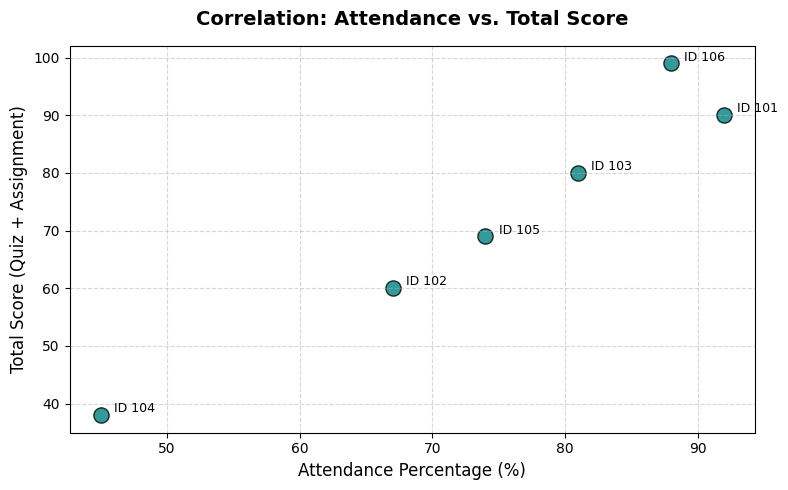

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['attendance_percent'], df['total_score'], color='teal', s=120, edgecolor='black', alpha=0.8)

# Annotate each point with the corresponding student ID
for i in range(len(df)):
    plt.annotate(f"ID {df['student_id'][i]}",
                 (df['attendance_percent'][i] + 1, df['total_score'][i] + 0.5),
                 fontsize=9)

plt.title('Correlation: Attendance vs. Total Score', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Attendance Percentage (%)', fontsize=12)
plt.ylabel('Total Score (Quiz + Assignment)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Chart 2: Bar Chart (Lab Completion vs. Average Quiz Score)
Objective: Determine whether students who complete all lab exercises tend to score better on their quizzes.


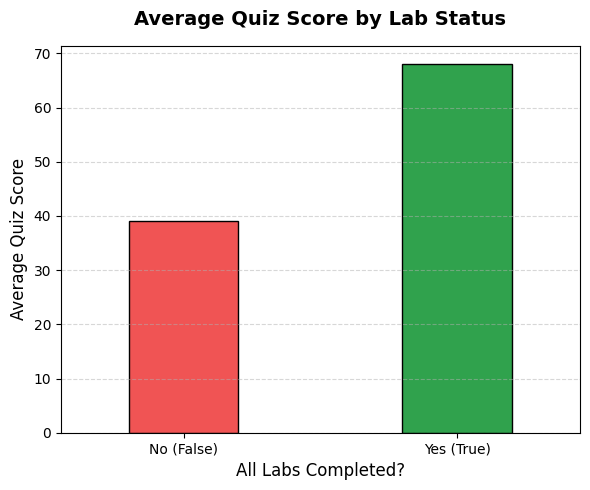

In [ ]:
# Grouping the data to find the average quiz score for each group
avg_quiz_by_lab = df.groupby('lab_completed')['quiz_score'].mean()

plt.figure(figsize=(6, 5))
# Customizing bar colors: Light Crimson for incomplete labs, Soft Mint for completed labs
colors = ['#f05454', '#30a24d']
avg_quiz_by_lab.plot(kind='bar', color=colors, edgecolor='black', width=0.4)

plt.title('Average Quiz Score by Lab Status', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('All Labs Completed?', fontsize=12)
plt.ylabel('Average Quiz Score', fontsize=12)
plt.xticks([0, 1], ['No (False)', 'Yes (True)'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Chart 3: Pie Chart (Distribution of Attendance Categories)
Objective: Use a pie chart to visualize the overall proportion of the class across different attendance bands.

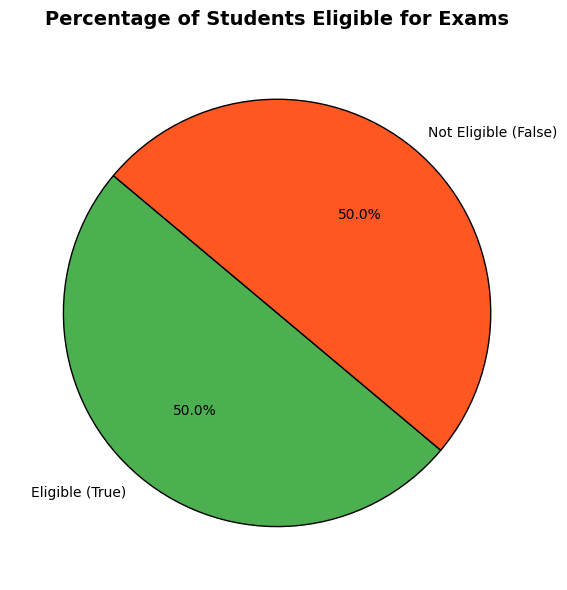

In [ ]:
# 1. Change this line to use your 'eligible' column
eligibility_counts = df['eligible'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(eligibility_counts,
        labels=['Eligible (True)', 'Not Eligible (False)'], # Updated labels to match your data
        autopct='%1.1f%%',
        startangle=140,
        colors=['#4CAF50', '#FF5722'], # Green for True, Red for False
        wedgeprops={'edgecolor': 'black', 'linewidth': 1, 'antialiased': True})

# 2. Update the title to match your feature
plt.title('Percentage of Students Eligible for Exams', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [ ]:
subjects = ["Python", "Math", "AI", "Data"]

In [ ]:
print(subjects)
print(subjects[0])
print(subjects[-1])

In [ ]:
dict = {"college name":gla,"section":ca,"city":Mathura,}

In [ ]:
dict ={name:"Adi Jain", class :"CA", city:"Mathura"}
grade={A:"A+",B:"B+"}

In [ ]:
college = {
    "college_name": "GLA",
    "section": "CB",
    "city": "Mathura",
    "grades": ["A", "A+", "B", "B+"]
}

In [ ]:
for student in students:
    if student["grade"] == "A+":
        print(student["name"])


In [ ]:
students = [
    {
        "college_name": "GLA",
        "Class": "CB",
        "city": "mathura",
        "grade": "A"
    },
    {
        "college_name": "IIT Delhi",
        "Class": "CS",
        "city": "Delhi",
        "grade": "A+"
    },
    {
        "college_name": "NIT Trichy",
        "Class": "IT",
        "city": "Tiruchirappalli",
        "grade": "B+"
    },
    {
        "college_name": "BHU",
        "Class": "EE",
        "city": "Varanasi",
        "grade": "B"
    },
    {
        "college_name": "DTU",
        "Class": "ME",
        "city": "Delhi",
        "grade": "A"
    }
]
for student in students:
    if student["grade"] == "A+":
        print(student)

In [ ]:
marks = 72

if marks>=80:
  print("distinction")
elif marks>=40 and marks<=79:
  print("pass")
else:
  print('fail')


In [ ]:
if marks %2==0:
    print("even marks")
else:
    print("odd marks")


In [ ]:
age=int(input())
if age<13:
  print("child")
elif age>13 and age<19:
  print("teenager")
else:
  print("Old")

In [ ]:
students_list = [
    {
        "name": "Adi Jain",
        "age": 12,
        "attendance": "92%",
        "marks": 85,
        "lab_assignment": True
    },
    {
        "name": "Raj Gupta",
        "age": 15,
        "attendance": "95%",
        "marks": 92,
        "lab_assignment": True
    },
    {
        "name": "Rahul Verma",
        "age": 21,
        "attendance": "78%",
        "marks": 64,
        "lab_assignment": False
    },
    {
        "name": "Priya Rai",
        "age": 19,
        "attendance": "88%",
        "marks": 78,
        "lab_assignment": True
    },
    {
        "name": "Vikram Singh",
        "age": 11,
        "attendance": "60%",
        "marks": 45,
        "lab_assignment": False
    }
]
for student in students:
    if student["lab_assignment"] == False:
        result = "Lab Assignment Not Submitted"
    elif student["attendance"] < 75:
        result = "Low Attendance"
    elif student["marks"] >= 70:
        result = "Distinction"
    elif student["marks"] >= 40:
        result = "Pass"
    else:
        result = "Fail"

    print(student["name"], "-", result)